In [29]:
import os
import re
import nltk
from nltk import Tree

import spacy
#spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm") 

import pandas as pd
import numpy as np

import textdescriptives as td

from dataset_evaluation.utils import add_column
from dataset_evaluation.evaluation_framework import EvaluationFramework

import folia.main as folia
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from datasets import load_dataset

import pylangacq

# Datasets

## Generated corpus (tinystories)

In [30]:
# generated corpus
tinystories = load_dataset('roneneldan/TinyStories', split='train[:1%]')
len(tinystories)

21197

In [31]:
df_tinystories = pd.DataFrame(tinystories['text'], columns=['story'])
df_tinystories

,story
0,"One day, a little girl named Lily found a need..."
1,"Once upon a time, there was a little car named..."
2,"One day, a little fish named Fin was swimming ..."
3,"Once upon a time, in a land full of trees, the..."
4,"Once upon a time, there was a little girl name..."
...,...
21192,"One day, a strong girl named Lily went for a w..."
21193,"Once upon a time, there was a team of gifted a..."
21194,"Once upon a time, there was a driver. He was a..."
21195,"One day, a confused little dog named Spot was ..."


## Narrative dataset (Nipopolou)

In [32]:
nico_path = '/Users/sabijn/Documents/PhD/Datasets/CHILDES_Nicolopoulou'
nicolopoulou = pylangacq.read_chat(nico_path)

df_narrative = pd.DataFrame({
    "text": [s.text() for s in nicolopoulou.stories()]
})

## Reference corpus (standard)

In [33]:
ref_corpus_standard = pd.read_csv('datasets/CCdep_without_deps_part.csv')

## Reference corpus (spoken)

In [34]:
ref_spoken_u_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CV_unigrams_part.csv')
ref_spoken_b_csv  = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CV_bigrams_part.csv')
ref_spoken_t_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CV_trigrams_part.csv')

# Evaluations

Linguistic annotations
- Syntactic tree depth per sentence according to the WNU_2022 paper (van Duijn & van Dijk, 2022)
- Average no. of complements per utterance
- Sentence complexity (words before the root)
- Lexical diversity
    - Standard TTR (not implemented).  
    Dividing the number of unique tokens (types) by the total number of tokens. 
    - msTTR (mean segmental type-token ratio (TTR)): 
    
    - maTTR (moving average TTR)
    - MTLD (average number of words for which a consecutive TTR is maintained).  
    Measure of Textual Lexical Diversity.
    - MTLD (moving)
    - MTLD (bidirectional)
    - HDD (bidirectional)
- Vendi score
- Dependency constrained perplexity
- Regular perplexity
- Past tense use
- MAUVE (diversity)

In [7]:
eval_f = EvaluationFramework(language='en')

## Syntatic tree depth
-- van Duijn & van Dijk (2022)

In [8]:
eval_f.add_pipe('syntactic_depth')


## Average no. of complements per utterance

In [9]:
eval_f.add_pipe('average_components')

## Sentence complexity
-- ChiSCor (2023) - Average number of words before the root

In [10]:
eval_f.add_pipe('wbr_average')

## Lexical diversity
-- ChiSCor (2023)

In [11]:
eval_f.add_pipe('lexical_diversity')

## Dependency distance
-- ChiSCor (2023)

In [12]:
eval_f.add_pipe('dependency_distance')

## Run pipeline (real data)

In [13]:
eval_f.run_pipeline_on_df(df_narrative, 'text')

Running syntactic_depth
Running average_components
Running wbr_average
Running lexical_diversity
Running dependency_distance


,text,syntactic_depth,average_components,wbr_average,lexical_diversity,dependency_distance
0,I go to bed. Joella tucks me in. I get my jamm...,2.0,0.0,1.0,{'moving_mtld': 15.58695652173913},1.518519
1,my mom picks me up. I go home with my mom. and...,3.0,0.0,2.0,{'moving_mtld': 19.066666666666666},1.578947
2,two princesses first and two babies. and a mot...,5.0,0.0,1.0,{'moving_mtld': 16.575757575757574},1.653846
3,a princess and a queen and a castle. and two p...,3.0,0.0,1.0,{'moving_mtld': 12.48},1.828571
4,a princess and then a prince married her. and ...,3.0,0.0,1.0,{'moving_mtld': 14.869565217391305},2.071429
...,...,...,...,...,...,...
1224,once there was a Power Puff girl. and that was...,4.0,0.0,2.0,{'moving_mtld': 19.514705882352942},2.000000
1225,once there was a dinosaur. and then there was ...,4.0,1.0,2.0,{'moving_mtld': 18.32941176470588},2.129032
1226,once there was the Power Puff Girl Gang. and t...,4.0,1.0,2.0,{'moving_mtld': 18.0},2.144928
1227,once there was a karate master. and he killed ...,3.0,1.0,2.0,{'moving_mtld': 21.77027027027027},2.236364


## Run pipeline (tinystories)

In [17]:
tiny_tinystories = df_tinystories[:1200].copy()

In [18]:
eval_f.run_pipeline_on_df(tiny_tinystories, 'story')

Running syntactic_depth
Running average_components
Running wbr_average
Running lexical_diversity
Running dependency_distance


,story,syntactic_depth,average_components,wbr_average,lexical_diversity,dependency_distance
0,"One day, a little girl named Lily found a need...",5.333333,1.200000,2.400000,{'moving_mtld': 47.38607594936709},2.350365
1,"Once upon a time, there was a little car named...",5.000000,1.400000,2.400000,{'moving_mtld': 44.925},2.022901
2,"One day, a little fish named Fin was swimming ...",5.000000,2.800000,2.400000,{'moving_mtld': 50.30952380952381},2.731844
3,"Once upon a time, in a land full of trees, the...",5.000000,0.800000,5.400000,{'moving_mtld': 44.57837837837838},2.294872
4,"Once upon a time, there was a little girl name...",5.333333,0.800000,3.400000,{'moving_mtld': 48.38666666666666},2.299213
...,...,...,...,...,...,...
1195,Jack was a young boy. He wanted to do somethin...,3.600000,0.777778,0.777778,{'moving_mtld': 46.03846153846154},2.181102
1196,Once upon a time there was a happy little girl...,3.800000,0.777778,1.666667,{'moving_mtld': 56.968586387434556},2.146667
1197,Once there was a boy called Jake. Jake wanted ...,2.800000,0.428571,1.285714,{'moving_mtld': 58.07627118644068},2.524272
1198,Once upon a time there was a kitty. She was pl...,5.000000,1.428571,4.000000,{'moving_mtld': 44.817142857142855},2.280822


## MAUVE
-- Pillutla (2021), see also Peeperkorn (NYP)

https://github.com/krishnap25/mauve.  
https://pypi.org/project/mauve-text/

In [ ]:
# crashed because it needs at least 897 samples 😅
from mauve import compute_mauve

p_text = list(fairytale_unique.values())
q_text = tinystories_part

# out = compute_mauve(p_text=p_text, q_text=q_text, device_id=0, max_text_length=256, verbose=False)
# plt.plot(out.divergence_curve[:, 1], out.divergence_curve[:, 0])

## Vendi score
-- [Friedman (2023) The Vendi Score: A Diversity Evaluation Metric for Machine Learning](https://github.com/vertaix/Vendi-Score)

In [ ]:
from vendi_score import text_utils

# The higher, the more diversity
print(list(map(str, list(nlp(example['story_raw']).sents))))
ngram_vs = text_utils.ngram_vendi_score(list(map(str, list(nlp(example['story_raw']).sents))), ns=[1, 2])

print(f"N-grams: {ngram_vs:.02f}")


['er was er eens een meisje.\n', 'ze wou heel graag buiten spelen.\n', 'het mocht niet van haar moeder.', '\n', 'ze ging toch naar buiten en toen zei haar moeder waar ga je naartoe?', '\n', 'en het meisje zei ik ga naar buiten.\neinde.']
N-grams: 3.93


/opt/miniconda3/envs/storylmdata/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


## Local contextuality

In [ ]:
#TODO: Minimize vendi score between sentences?

## Vocabulary perplexity
-- code from ChiSCor (2023) but not published

### Load lexicon & example

In [53]:
df_dp_lexicon = pd.read_csv('datasets/CCdeplexicon_part.csv') # remember that this is also a partly calculated one 
df_dp_lexicon_new = pd.read_csv('datasets/CCdep_without_deps_part.csv')

In [56]:
df_dp_lexicon_new = df_dp_lexicon_new.drop('Unnamed: 0', axis=1)

### Bigram perplexity correct!

In [ ]:
def extract_PP_bigram(story, lexicon, alpha=1.0):
    """
    lexicon: DataFrame with columns ['lemma1','lemma2','freq'] where 'freq' is bigram count in the reference corpus
    nlp: assumed to be defined (spaCy pipeline)
    """
    # Build bigram counts for the story
    doc = nlp(story)
    story_bigrams = [(doc[i].lemma_, doc[i+1].lemma_) for i in range(len(doc)-1)]
    if not story_bigrams:
        return None
    story_counts = Counter(story_bigrams)

    # Prep corpus counts: (lemma1) totals
    hist_totals = lexicon.groupby('lemma1')['freq'].sum().rename('hist_total')
     # |V(w_{i})| (unique lemma 2 with this lemma1)
    V_by_hist = lexicon.groupby('lemma1')['lemma2'].nunique().rename('hist_vocab') 
    
    # fallback vocabulary size per history for unseen lemma1's
    global_V = lexicon['lemma2'].nunique()

    # Fetch counts for the story bigrams from corpus (0 if unseen)
    story_df = (
        pd.DataFrame(story_counts.items(), columns=['bigram','count'])
          .assign(lemma1=lambda df: df['bigram'].str[0],
                  lemma2=lambda df: df['bigram'].str[1])
          .drop(columns='bigram')
          .merge(lexicon, how='left', on=['lemma1','lemma2'])
    )
    story_df['freq'] = story_df['freq'].fillna(0)

    # Attach denominators and vocab sizes per history
    story_df = (story_df
        .merge(hist_totals, how='left', on='lemma1')
        .merge(V_by_hist, how='left', on='lemma1'))

    # For histories never seen in the corpus, use 0 for hist_total and a fallback vocab size
    story_df['hist_total'] = story_df['hist_total'].fillna(0)
    story_df['hist_vocab'] = story_df['hist_vocab'].fillna(global_V)

    # Add-one smoothing and log-probs
    # p(lemma2 | lemma1) = (c_bigram + alpha) / (c_history + alpha * V_history)
    denom = story_df['hist_total'] + alpha * story_df['hist_vocab']
    # Avoid zero denom if both are zero (edge case when global_V might be 0)
    denom = denom.replace(0, np.finfo(float).tiny)

    p = (story_df['freq'] + alpha) / denom
    logp = np.log(p)

    # 6) Perplexity over the full sequence (weighted by counts)
    N = story_df['count'].sum()
    avg_logp = (logp * story_df['count']).sum() / N
    ppl = np.exp(-avg_logp)

    return ppl

In [69]:
for i in range(10):
    print(extract_PP_bigram(tiny_tinystories.iloc[i]['story'], df_dp_lexicon_new))

187.04027856212986
142.4663374230653
122.89304630359754
117.82529485071785
295.7400886193272
127.7470216568584
231.19897254025193
237.98489129395583
154.2797513074611
139.3806466350035


### Perplexity

In [ ]:
def extract_bigrams(story, nlp):
    """
    Return Counter of (lemma_{i-1}, lemma_i) from the story.
    """
    doc = nlp(story)
    pairs = [(doc[i].lemma_, doc[i+1].lemma_) for i in range(len(doc)-1)]

    return Counter(pairs)

def _collect_dep_pairs(node, bag: Counter):
    """
    Collect linguistically constrained pairs.
    Here: (child -> head) for selected relations.
    Adjust the rules to your needs, but keep orientation consistent with lexicon.
    """
    # Verbal heads: subject/object relations
    if node.pos_ in ('VERB', 'AUX'):
        for child in node.children:
            if child.dep_ in ('nsubj', 'nsubj:pass', 'obj'):
                bag[(child.lemma_, node.lemma_)] += 1

    # Nominal heads: adjectival modifiers
    if node.pos_ == 'NOUN':
        for child in node.children:
            if child.dep_ == 'amod' and child.pos_ == 'ADJ':
                bag[(child.lemma_, node.lemma_)] += 1

    # Recurse
    for child in node.children:
        _collect_dep_pairs(child, bag)

def extract_dep_pairs(story, nlp):
    """
    Return Counter of linguistically constrained (lemma1, lemma2) pairs.
    Current orientation: (dependent lemma, head lemma).
    """
    bag = Counter()
    for sent in nlp(story).sents:
        _collect_dep_pairs(sent.root, bag)
    return bag


def compute_perplexity_from_counts(
    story_counts: Counter,
    lexicon: pd.DataFrame,
    *,
    alpha: float = 1.0,
    vocab: str = "global",   # "global" or "per_history"
    return_frame: bool = False
):
    """
    Compute perplexity for (lemma1, lemma2) counts using conditional bigram probabilities with Laplace smoothing.

    lexicon: DataFrame with ['lemma1', 'lemma2', 'freq'] from the reference corpus.
    alpha: Laplace smoothing strength (α=1 is add-one).
    vocab:
      - "global": use |{lemma2}| as V for all histories (textbook Laplace).
      - "per_history": use |{lemma2: seen after lemma1}| as V(lemma1); falls back to global V when unknown.
    return_frame: also return a diagnostic DataFrame with probs and components.
    """
    if not story_counts:
        return (None, pd.DataFrame(columns=['lemma1','lemma2','count'])) if return_frame else None

    # Story pairs + counts
    story_df = (
        pd.DataFrame([(l1, l2, c) for (l1, l2), c in story_counts.items()],
                     columns=['lemma1','lemma2','count'])
        .merge(lexicon, how='left', on=['lemma1','lemma2'])
    )
    story_df['freq'] = story_df['freq'].fillna(0)

    # Denominators: totals per history (c(lemma1))
    hist_totals = lexicon.groupby('lemma1')['freq'].sum().rename('hist_total')
    story_df = story_df.merge(hist_totals, how='left', on='lemma1')
    story_df['hist_total'] = story_df['hist_total'].fillna(0)

    # Vocabulary sizes
    global_V = int(lexicon['lemma2'].nunique()) or 1
    if vocab == "per_history":
        V_by_hist = lexicon.groupby('lemma1')['lemma2'].nunique().rename('hist_vocab')
        story_df = story_df.merge(V_by_hist, how='left', on='lemma1')
        story_df['hist_vocab'] = story_df['hist_vocab'].fillna(global_V)
    else:
        story_df['hist_vocab'] = global_V

    # Smoothed conditional probabilities p(lemma2 | lemma1)
    denom = story_df['hist_total'] + alpha * story_df['hist_vocab']

    denom = denom.replace(0, np.finfo(float).tiny)  # Avoid log(0)
    probs = (story_df['freq'] + alpha) / denom
    logp = np.log(probs)

    # Perplexity over total pair count (weights by story counts)
    N = int(story_df['count'].sum())
    if N == 0:
        return (None, story_df) if return_frame else None

    avg_logp = (logp * story_df['count']).sum() / N
    ppl = float(np.exp(-avg_logp))

    if return_frame:
        out = story_df.copy()
        out['prob'] = probs
        return ppl, out[['lemma1','lemma2','count','freq','hist_total','hist_vocab','prob']]
    
    return ppl


# ---------- Simple orchestrator ----------

def perplexity_for_creativity(
    story: str,
    lexicon: pd.DataFrame,
    nlp,
    *,
    mode: str = "bigram",     # "bigram" or "dep"
    alpha: float = 1.0,
    vocab: str = "global",    # "global = laplace" or "per_history = witten-bell smoothing"
    return_frame: bool = False,
):
    """
    General entry point. Chooses the extractor and computes perplexity.

    mode="bigram": surface bigrams (lemma_{i-1}, lemma_i)
    mode="dep": linguistically constrained pairs (dependent -> head)
    IMPORTANT: Your lexicon must use the same (lemma1, lemma2) orientation as the extractor you pick.
    """
    if mode == "bigram":
        counts = extract_bigrams(story, nlp)
    elif mode == "dep":
        counts = extract_dep_pairs(story, nlp)
    else:
        raise ValueError("mode must be 'bigram' or 'dep'")

    return compute_perplexity_from_counts(
        counts, lexicon, alpha=alpha, vocab=vocab, return_frame=return_frame
    )


In [77]:
for i in range(10):
    print('*' * 10)
    print(perplexity_for_creativity(tiny_tinystories.iloc[i]['story'], df_dp_lexicon_new, nlp, mode="dep", vocab="per_history"))
    print(perplexity_for_creativity(tiny_tinystories.iloc[i]['story'], df_dp_lexicon_new, nlp, mode="dep", vocab="global"))

**********
791.9710975593339
10624
7228.3531640132
**********
239.32594609120824
10624
7555.123725364449
**********
24.30606702188126
10624
7383.8415506054735
**********
93.20407182771736
10624
4454.186963729856
**********
770.4838066889189
10624
5270.2175008801805
**********
71.14326077911748
10624
5487.82875883604
**********
1049.6463494616826
10624
5448.035472713413
**********
261.54617379074307
10624
7237.720808455682
**********
20.550333382772997
10624
9758.05903107801
**********
97.10294130844514
10624
7213.847176718179


In [39]:
tiny_tinystories['story_PP_dep'] = tiny_tinystories.apply(lambda row: extract_PP_constrained(row['story'], df_dp_lexicon), axis = 1) 

### Plotting and investigating

In [40]:
def plot_pp_histogram(data, binsize=30, figure_size=(8,6), title='Dependency-constraint perplexities'):
    plt.figure(figsize=figure_size)
    plt.hist(data, bins=binsize, edgecolor='black')
    plt.title(title)
    plt.xlabel('Perplexity')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

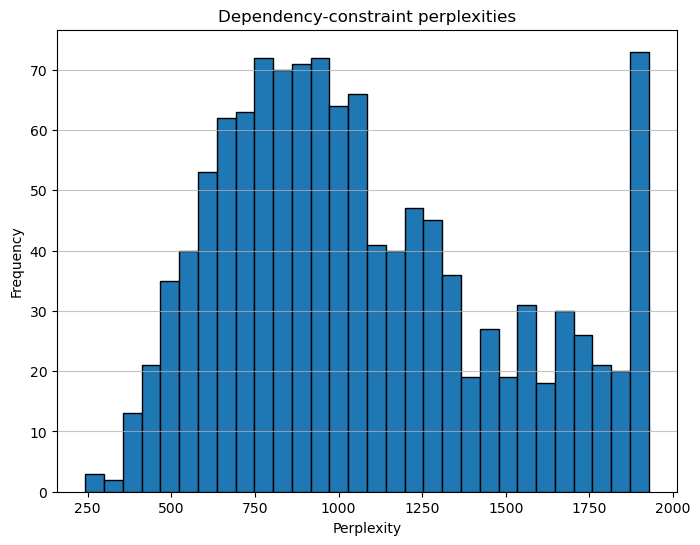

In [41]:
# Plot histogram
plot_pp_histogram(tiny_tinystories['story_PP_dep'])

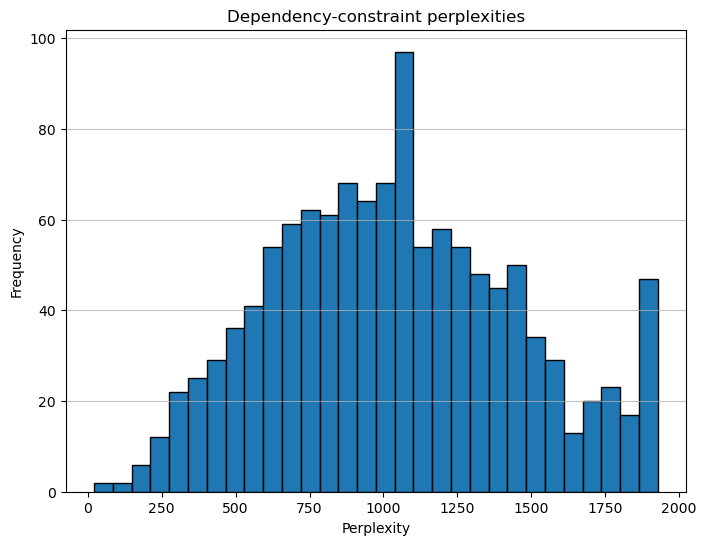

In [66]:
# Plot histogram
plot_pp_histogram(tiny_tinystories['story_PP_dep_new'])

In [ ]:
high_pp_dep_idx = df.index[(df['story_PP_dep'] > 5300) & (df['story_PP_dep'] < 7000)].tolist()

In [ ]:
print('*' * 100)
print(f'Dependency constrained perplexity ({len(high_pp_dep_idx)})')
for idx in high_pp_dep_idx:
    print('-' * 50)
    print(df.iloc[idx]['story_PP_dep'])
    print(df.iloc[idx]['story_raw'])
    print(extract_PP_constrained(df.iloc[idx]['story_raw'], df_dp_lexicon, output_pairs=True)[1])

****************************************************************************************************
Dependency constrained perplexity (14)
--------------------------------------------------
6164.965654513117
een keer naar de Efteling naar enge achtbanen. 
toen gebeurde er zo ik ging naar de.
ik weet niet meer welke achtbaan.
de Python.
en daarna ging ik gewoon op de kop twee keer. 
en dat was bij Rotterdam.
                   lemma  freq
0     ('eng', 'achtban')     2
1     ('eng', 'achtban')     1
2  ('achtbaan', 'weten')     1
--------------------------------------------------
5492.359998984962
er was eens één sok. 
die sok ging uit de kast. 
en die liep dus toen ging die naar beneden. 
en toen ging iemand hem pakken. 
en toen werd hij boos op die sok.
             lemma  freq
0  ('sok', 'zijn')     2
1  ('sok', 'gaan')     1
--------------------------------------------------
5886.5656936079395
d'r was een politie en die zei.
en d'r waren honderd boeven en die zeiden.
en ze waren al

## Grammaticality

$G(story) = \dfrac{\sum^k_{i=1}(G(s_i))}{k}$, with $s$ a sentence in the story.  
  
$G(sentence) = P(seq) = \log(\sqrt[n]{\prod_{i=1}^n \left( P(K_i) \right)})$.  
  
$P(K_i) = P(t_3t_2t_1) = \lambda_1 \cdot P(t_3|t_1t_2) + \lambda_2 \cdot P(t_3|t_2) + \lambda_3 \cdot P(t_3)$, where  
  
- where $\lambda_1 + \lambda_2 + \lambda_3 = 1$, ($\lambda_1 = 0.5, \lambda_2 = 0.3, \lambda_3 = 0.2 \rightarrow$ vadlapudi (2010))
- $P(t_3|t_1t_2) = \dfrac{f(t_1t_2t_3)}{f(t_1t_2)}$.  
- $P(t_3|t_2) = \dfrac{f(t_2t_3)}{f(t_2)}$.  
- $P(t_3) = \dfrac{f(t_3)}{\sum_{\forall t_i} f(t_i)}$


In [19]:
import math

class Grammaticality():
    L1, L2, L3 = 0.5, 0.3, 0.2       
    MIN_PROB = 1e-12

    def __init__(self, nlp, unigram_csv, bigram_csv, trigram_csv):
        self.nlp = nlp
        self.unigram, self.bigram, self.trigram, self.total_u = self._load_counts(unigram_csv, bigram_csv, trigram_csv)

    # ---------- Load counts ----------
    def _load_counts(self, unigram_csv, bigram_csv, trigram_csv):
        # Unigrams: columns ['pos', 'freq']
        df_u = pd.read_csv(unigram_csv)
        unigram = Counter(dict(zip(df_u["pos"], df_u["freq"])))

        # Bigrams: columns ['pos1','pos2','freq'] meaning (t2, t3)
        df_b = pd.read_csv(bigram_csv)
        bigram = Counter({(r.pos1, r.pos2): int(r.freq) for r in df_b.itertuples(index=False)})

        # Trigrams: columns ['pos1','pos2','pos3','freq'] meaning (t1, t2, t3)
        df_t = pd.read_csv(trigram_csv)
        trigram = Counter({(r.pos1, r.pos2, r.pos3): int(r.freq) for r in df_t.itertuples(index=False)})

        total_unigrams = sum(unigram.values())

        return unigram, bigram, trigram, total_unigrams
    
    # ---------- Probability helpers ----------
    @staticmethod
    def _frac(num: int, den: int) -> float:
        return (num / den) if den > 0 else 0.0

    def _p_unigram(self, t3: str) -> float:
        # NOTE: the original formula had a small typo; it should be f(t3)/sum_i f(t_i)
        return self._frac(self.unigram.get(t3, 0), self.total_u)

    def _p_bigram(self, t2: str, t3: str) -> float:
        return self._frac(self.bigram.get((t2, t3), 0), self.unigram.get(t2, 0))

    def _p_trigram(self, t1: str, t2: str, t3: str) -> float:
        return self._frac(self.trigram.get((t1, t2, t3), 0), self.bigram.get((t1, t2), 0))

    def _p_interpolated(self, t1: str, t2: str, t3: str) -> float:
        # λ1 * P(t3|t1,t2) + λ2 * P(t3|t2) + λ3 * P(t3)
        p = self.L1 * self._p_trigram(t1, t2, t3) + self.L2 * self._p_bigram(t2, t3) + self.L3 * self._p_unigram(t3)
        return max(p, self.MIN_PROB)  # floor to avoid log(0)

    def _pos_tags(self, text: str):
        """Return list of lists of POS tags for each sentence."""
        doc = nlp(text)
        sents = []
        for i, sent in enumerate(doc.sents):
            tags = [t.pos_ for t in sent if not t.is_space]
            if tags:
                sents.append(tags)
        return sents
    
    def _score_sentence(self, tags):
        """
        G(sentence) = (1/n) * sum_{i=1..n} log P(K_i)
        For K_i, we use (t_{i-2}, t_{i-1}, t_i). For i < 3, we degrade context gracefully.
        """
        n = len(tags)
        if n == 0:
            return float("-inf")

        log_sum = 0.0
        for i, t3 in enumerate(tags):
            t2 = tags[i-1] if i-1 >= 0 else None
            t1 = tags[i-2] if i-2 >= 0 else None

            if t1 is None and t2 is None:
                # only unigram available
                p = self._p_unigram(t3)
            elif t1 is None:
                # bigram + unigram
                p = self.L2 * self._p_bigram(t2, t3) + self.L3 * self._p_unigram(t3)
                p = max(p, self.MIN_PROB)
            else:
                p = self._p_interpolated(t1, t2, t3)

            log_sum += math.log(p)

        return log_sum / n  # average log-prob (log of geometric mean)

    def _score_story(self, text: str):
        """
        G(story) = average of G(sentence) over all sentences in the text.
        Returns (G_story, per_sentence_scores, per_sentence_tags)
        """
        sentences = self._pos_tags(text)
        if not sentences:
            return float("-inf"), [], []

        scores = [self._score_sentence(tags) for tags in sentences]
        g_story = sum(scores) / len(scores)
        return g_story, scores, sentences 

    def evaluate(self, text: str) -> float:
        return self._score_story(text)

In [20]:
GramScore = Grammaticality(nlp, ref_spoken_u_csv, ref_spoken_b_csv, ref_spoken_t_csv)

In [21]:
df_narrative['story_grammaticality'] = df_narrative.apply(lambda row: GramScore.evaluate(row['text'])[0], axis = 1) 

In [22]:
def plot_histogram(data, binsize=30, figure_size=(8,6), title='Dependency-constraint perplexities', xlabel='Perplexity', ylabel='Frequency'):
    plt.figure(figsize=figure_size)
    plt.hist(data, bins=binsize, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='y', alpha=0.75)

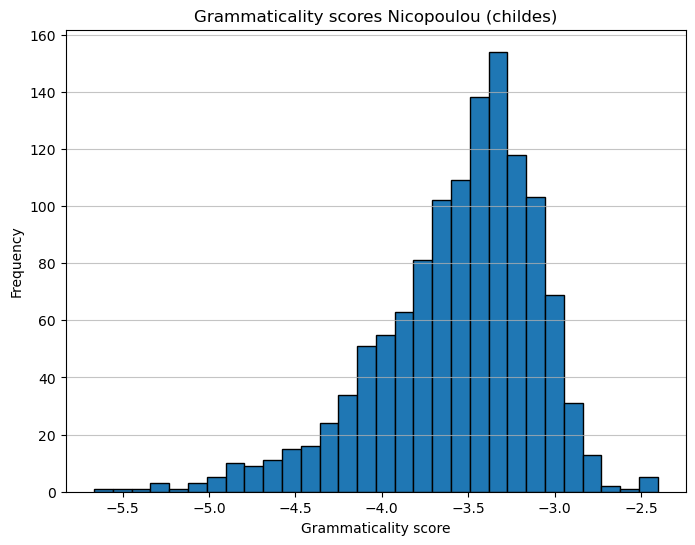

In [23]:
plot_histogram(df_narrative['story_grammaticality'], xlabel='Grammaticality score', title='Grammaticality scores Nicopoulou (childes)')

In [25]:
tiny_tinystories
tiny_tinystories['story_grammaticality'] = tiny_tinystories.apply(lambda row: GramScore.evaluate(row['story'])[0], axis = 1)

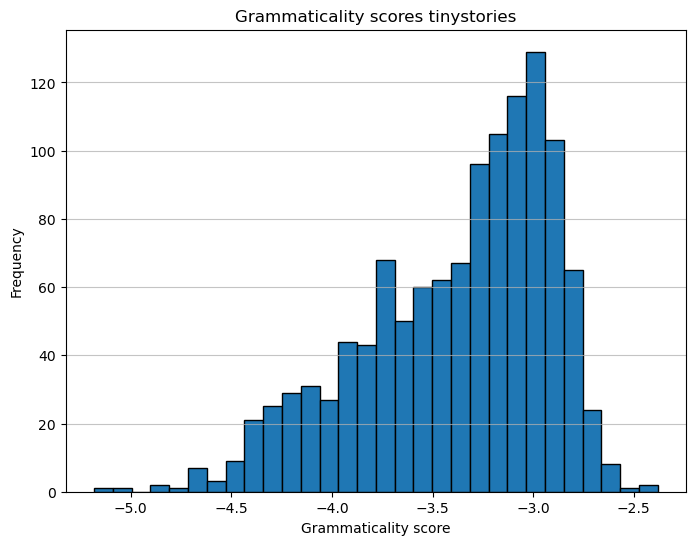

In [27]:
plot_histogram(tiny_tinystories['story_grammaticality'], xlabel='Grammaticality score', title='Grammaticality scores tinystories')

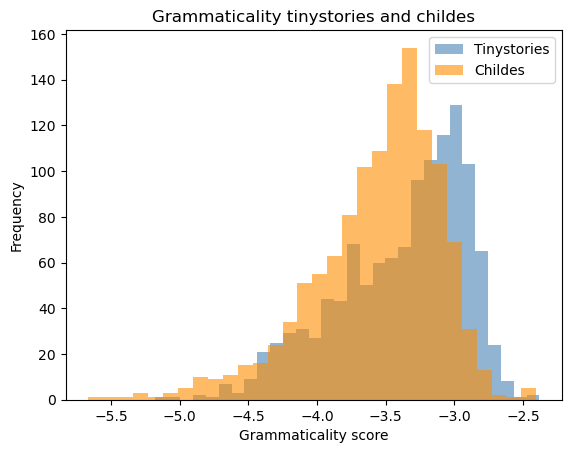

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Plot histograms
plt.hist(tiny_tinystories['story_grammaticality'], bins=30, color='steelblue', alpha=0.6, label='Tinystories')
plt.hist(df_narrative['story_grammaticality'], bins=30, color='darkorange', alpha=0.6, label='Childes')

# Add labels and legend
plt.xlabel('Grammaticality score')
plt.ylabel('Frequency')
plt.title('Grammaticality tinystories and childes')
plt.legend()

plt.show()